<a href="https://colab.research.google.com/github/useanynoms-commits/IDRA/blob/main/Assignment_18_%26_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make the plots look nicer
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# load the dataset
df = pd.read_csv('Day18_19_student_habits_performance.csv')

# check the shape first
print("Dataset shape:", df.shape)

# basic info about the dataset
print("\nDataset info:")
df.info()

# take a look at the first few rows
print("\nFirst 5 rows:")
print(df.head())

# check the column names and their types
print("\nColumn names and data types:")
print(df.dtypes)

Dataset shape: (1000, 16)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet

In [3]:
# separate the numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# student_id is just an id, drop it from the categorical list for stats
categorical_cols.remove('student_id')

# mean, median, mode for numeric columns
print("Mean, Median, Mode for Numeric Columns:")
print("-" * 50)

for col in numeric_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]
    print(f"{col}:")
    print(f"   Mean   = {mean_val:.2f}")
    print(f"   Median = {median_val:.2f}")
    print(f"   Mode   = {mode_val:.2f}")
    print()

# mode for categorical columns
print("\nMode for Categorical Columns:")
print("-" * 50)

for col in categorical_cols:
    mode_val = df[col].mode()[0]
    mode_count = df[col].value_counts()[mode_val]
    print(f"{col}:")
    print(f"   Mode   = {mode_val}")
    print(f"   Count  = {mode_count}")
    print()

Mean, Median, Mode for Numeric Columns:
--------------------------------------------------
age:
   Mean   = 20.50
   Median = 20.00
   Mode   = 20.00

study_hours_per_day:
   Mean   = 3.55
   Median = 3.50
   Mode   = 3.50

social_media_hours:
   Mean   = 2.51
   Median = 2.50
   Mode   = 3.10

netflix_hours:
   Mean   = 1.82
   Median = 1.80
   Mode   = 0.00

attendance_percentage:
   Mean   = 84.13
   Median = 84.40
   Mode   = 100.00

sleep_hours:
   Mean   = 6.47
   Median = 6.50
   Mode   = 6.50

exercise_frequency:
   Mean   = 3.04
   Median = 3.00
   Mode   = 3.00

mental_health_rating:
   Mean   = 5.44
   Median = 5.00
   Mode   = 4.00

exam_score:
   Mean   = 69.60
   Median = 70.50
   Mode   = 100.00


Mode for Categorical Columns:
--------------------------------------------------
gender:
   Mode   = Female
   Count  = 481

part_time_job:
   Mode   = No
   Count  = 785

diet_quality:
   Mode   = Fair
   Count  = 437

parental_education_level:
   Mode   = High School
   Count

In [4]:
# check missing values per column
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percent
})

# only show columns that actually have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Columns with Missing Values:")
print(missing_df)

print("\nTotal missing values in the dataset:", df.isnull().sum().sum())

# look at how parental_education_level is distributed including the missing ones
print("\nParental education level value counts (dropna=False):")
print(df['parental_education_level'].value_counts(dropna=False))

# also check the rows where parental_education_level is missing
print("\nSample rows where parental_education_level is missing:")
print(df[df['parental_education_level'].isnull()].head())

# check exam_score stats for rows with and without missing parental education
print("\nExam score stats - with parental education:")
print(df[df['parental_education_level'].notnull()]['exam_score'].describe())

print("\nExam score stats - without parental education (missing):")
print(df[df['parental_education_level'].isnull()]['exam_score'].describe())

Columns with Missing Values:
                          Missing Count  Missing Percentage
parental_education_level             91                 9.1

Total missing values in the dataset: 91

Parental education level value counts (dropna=False):
parental_education_level
High School    392
Bachelor       350
Master         167
NaN             91
Name: count, dtype: int64

Sample rows where parental_education_level is missing:
   student_id  age  gender  study_hours_per_day  social_media_hours  \
10      S1010   19  Female                  4.6                 3.7   
33      S1033   18  Female                  4.0                 0.9   
47      S1047   23  Female                  2.5                 2.9   
74      S1074   21  Female                  2.3                 1.0   
93      S1093   22    Male                  4.1                 2.5   

    netflix_hours part_time_job  attendance_percentage  sleep_hours  \
10            0.8            No                   77.6          5.8   
33 

In [5]:
# fill missing parental_education_level with the mode (High School)
mode_value = df['parental_education_level'].mode()[0]
print("Filling missing values with:", mode_value)

df['parental_education_level'] = df['parental_education_level'].fillna(mode_value)

# confirm no more missing values
print("\nMissing values after filling:")
print(df.isnull().sum().sum())

# double check the value counts now
print("\nUpdated parental_education_level value counts:")
print(df['parental_education_level'].value_counts())

Filling missing values with: High School

Missing values after filling:
0

Updated parental_education_level value counts:
parental_education_level
High School    483
Bachelor       350
Master         167
Name: count, dtype: int64


In [6]:
# numeric columns only, exclude student_id since it is just an id
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# function to detect outliers using the IQR method
def detect_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return len(outliers), lower, upper

print("Outlier Detection using IQR method:")
print("-" * 55)

for col in numeric_cols:
    count, lower, upper = detect_outliers(df, col)
    print(f"{col}: {count} outliers  (bounds: {lower:.2f} to {upper:.2f})")

Outlier Detection using IQR method:
-------------------------------------------------------
age: 0 outliers  (bounds: 12.38 to 29.38)
study_hours_per_day: 7 outliers  (bounds: -0.25 to 7.35)
social_media_hours: 5 outliers  (bounds: -0.70 to 5.70)
netflix_hours: 4 outliers  (bounds: -1.29 to 4.81)
attendance_percentage: 3 outliers  (bounds: 58.46 to 110.56)
sleep_hours: 2 outliers  (bounds: 3.05 to 9.85)
exercise_frequency: 0 outliers  (bounds: -5.00 to 11.00)
mental_health_rating: 0 outliers  (bounds: -4.50 to 15.50)
exam_score: 2 outliers  (bounds: 24.20 to 115.60)


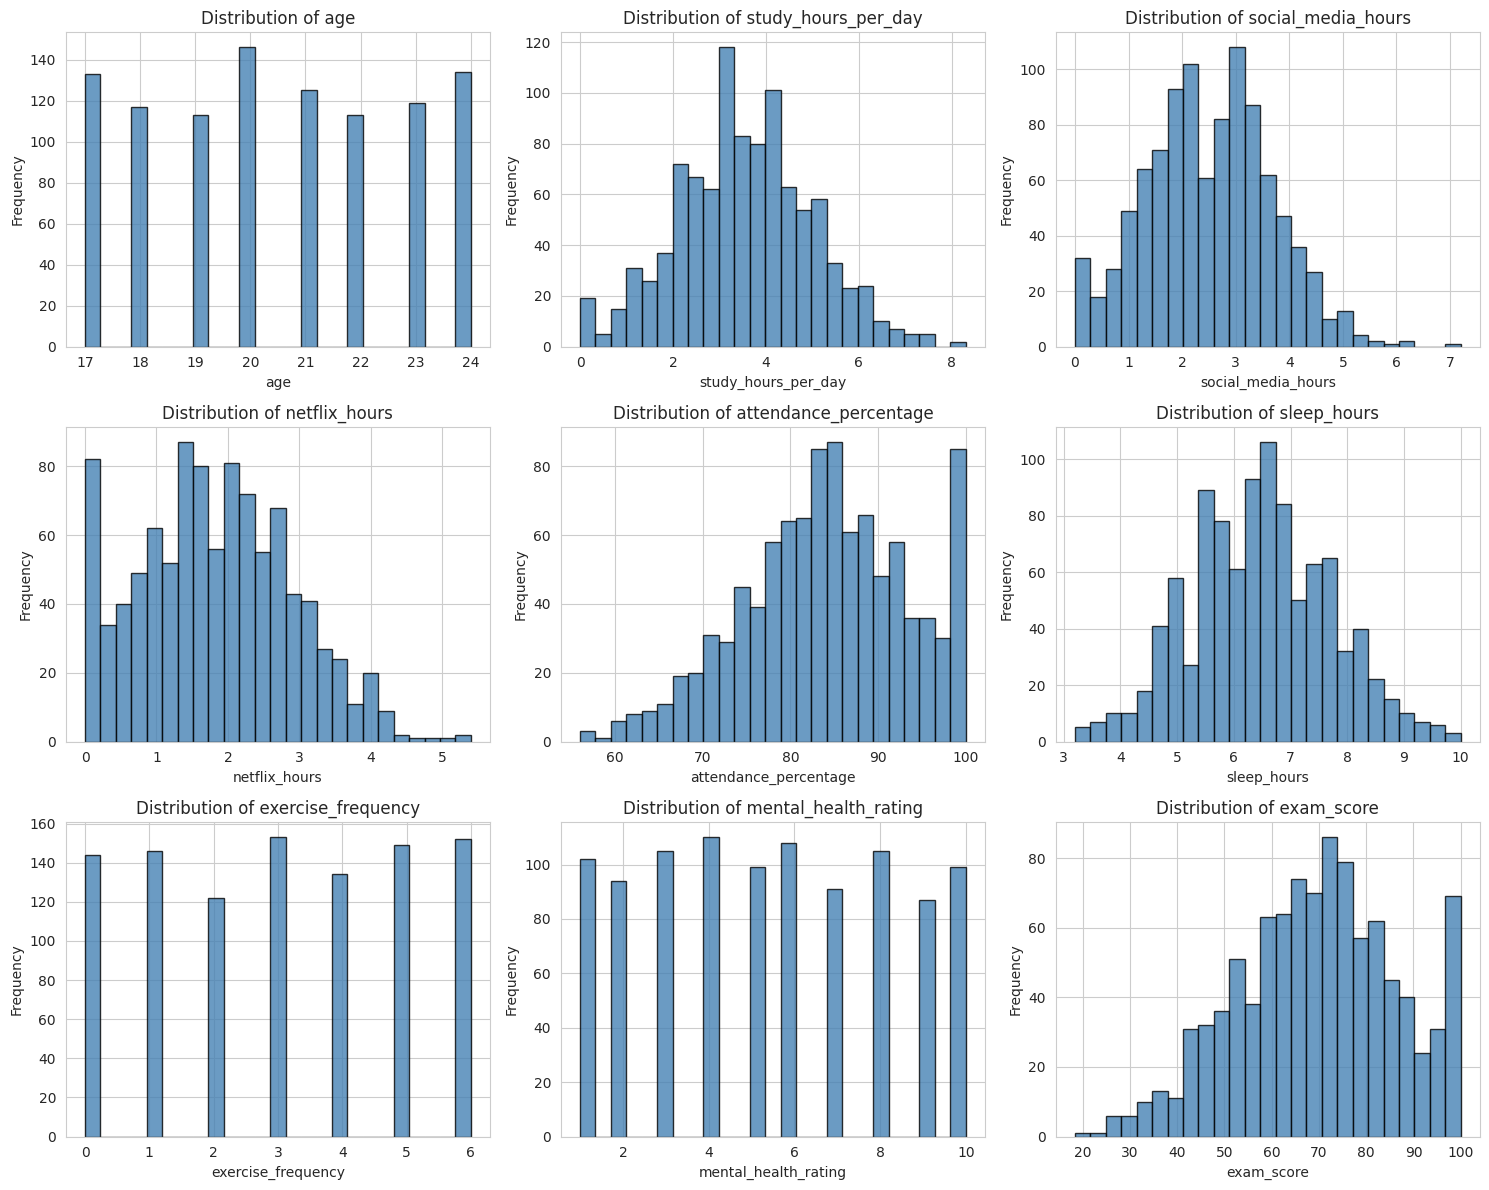

In [7]:
# plot histograms for all numeric columns
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=25, edgecolor='black', color='steelblue', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [8]:
# also print skewness and kurtosis to quantify the shape of each distribution
print("Skewness and Kurtosis of Numeric Columns:")

for col in numeric_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"{col}: skew = {skew:.3f}, kurtosis = {kurt:.3f}")

Skewness and Kurtosis of Numeric Columns:
age: skew = 0.008, kurtosis = -1.219
study_hours_per_day: skew = 0.054, kurtosis = -0.056
social_media_hours: skew = 0.120, kurtosis = -0.094
netflix_hours: skew = 0.237, kurtosis = -0.433
attendance_percentage: skew = -0.238, kurtosis = -0.391
sleep_hours: skew = 0.091, kurtosis = -0.214
exercise_frequency: skew = -0.032, kurtosis = -1.277
mental_health_rating: skew = 0.038, kurtosis = -1.189
exam_score: skew = -0.156, kurtosis = -0.420


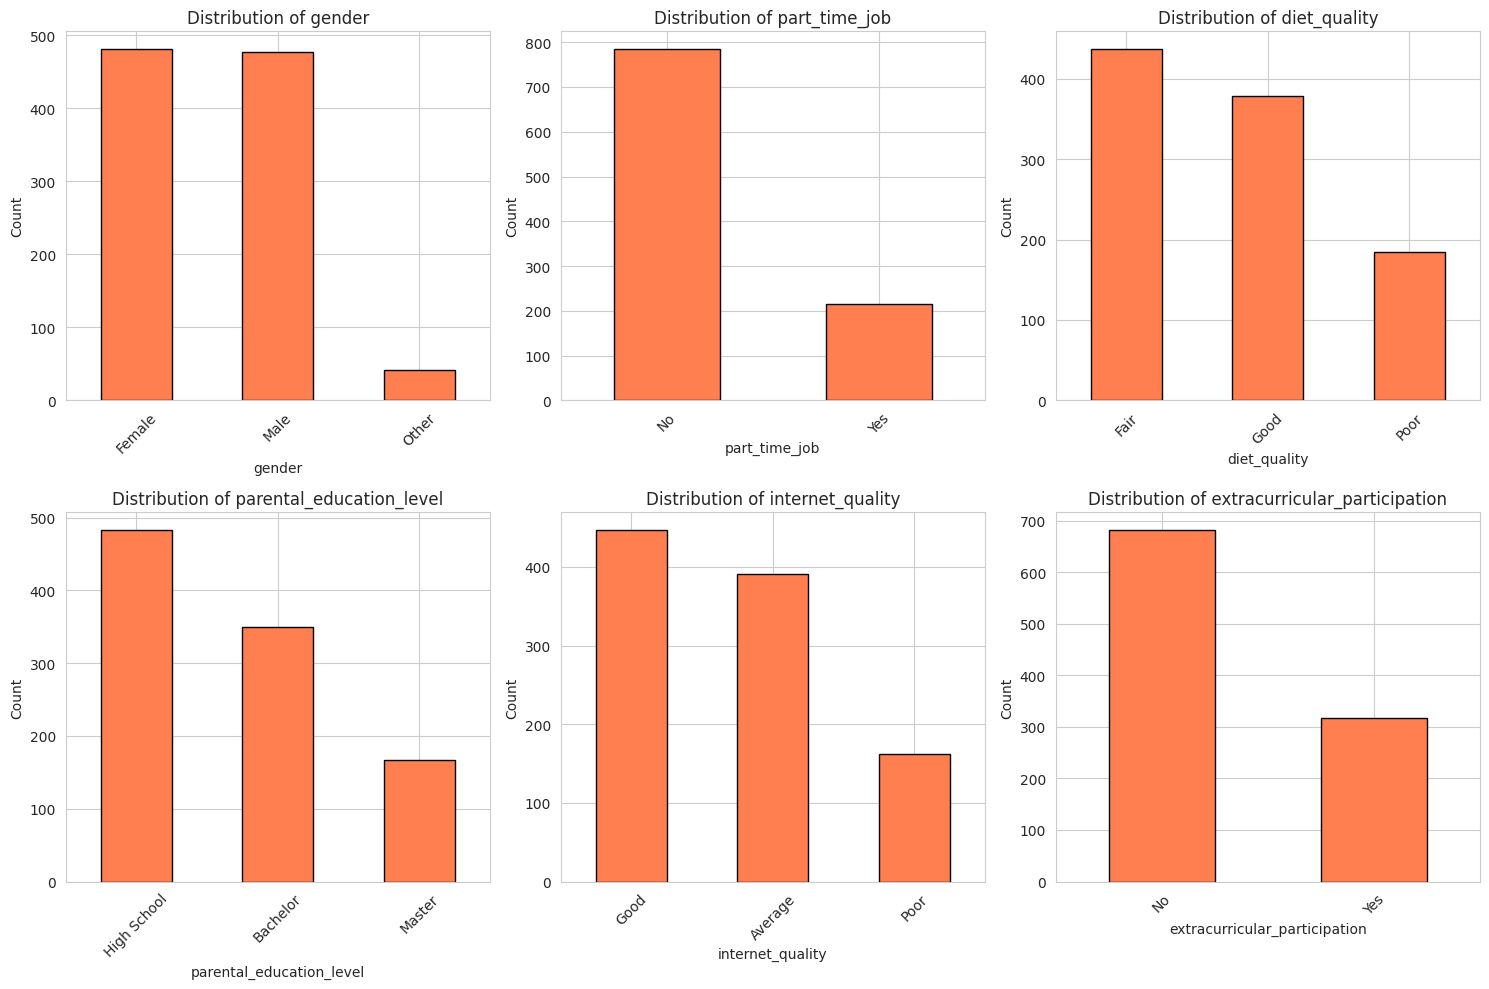

Categorical Variable Counts and Percentages:
-------------------------------------------------------

gender:
   Female: 481 (48.1%)
   Male: 477 (47.7%)
   Other: 42 (4.2%)

part_time_job:
   No: 785 (78.5%)
   Yes: 215 (21.5%)

diet_quality:
   Fair: 437 (43.7%)
   Good: 378 (37.8%)
   Poor: 185 (18.5%)

parental_education_level:
   High School: 483 (48.3%)
   Bachelor: 350 (35.0%)
   Master: 167 (16.7%)

internet_quality:
   Good: 447 (44.7%)
   Average: 391 (39.1%)
   Poor: 162 (16.2%)

extracurricular_participation:
   No: 682 (68.2%)
   Yes: 318 (31.8%)


In [9]:
# categorical columns, excluding student_id
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('student_id')

# plot bar charts for each categorical variable
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black', color='coral')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# print exact counts and percentages
print("Categorical Variable Counts and Percentages:")
print("-" * 55)

for col in cat_cols:
    print(f"\n{col}:")
    counts = df[col].value_counts()
    percents = df[col].value_counts(normalize=True) * 100
    for val in counts.index:
        print(f"   {val}: {counts[val]} ({percents[val]:.1f}%)")

Correlation of Numeric Features with Exam Score:
-------------------------------------------------------
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


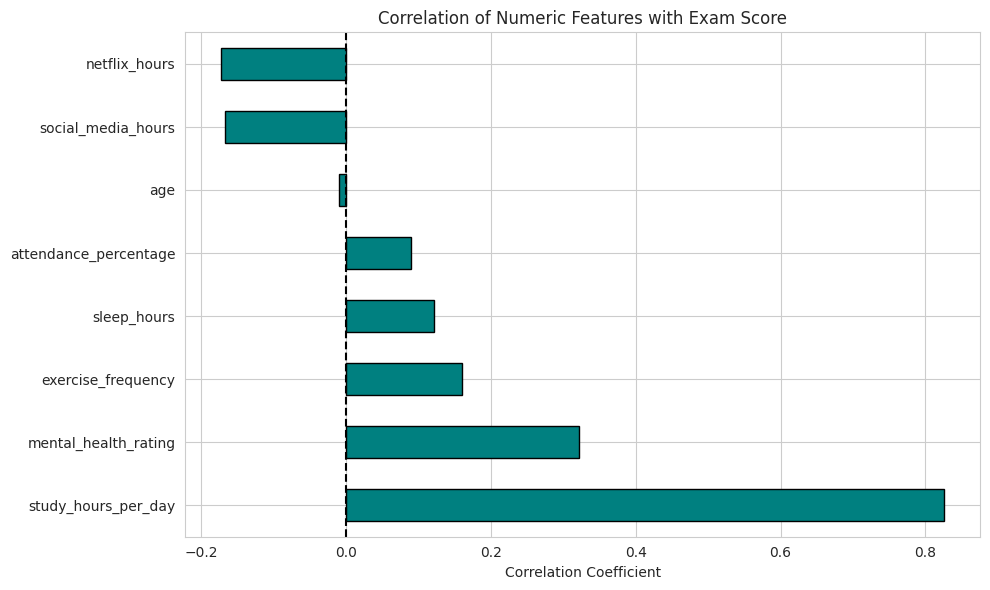

In [10]:
# correlation of numeric features with exam_score
corr_matrix = df[numeric_cols].corr()
exam_corr = corr_matrix['exam_score'].drop('exam_score').sort_values(ascending=False)

print("Correlation of Numeric Features with Exam Score:")
print("-" * 55)
print(exam_corr)

# visual bar chart of correlations
plt.figure(figsize=(10, 6))
exam_corr.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Correlation of Numeric Features with Exam Score')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

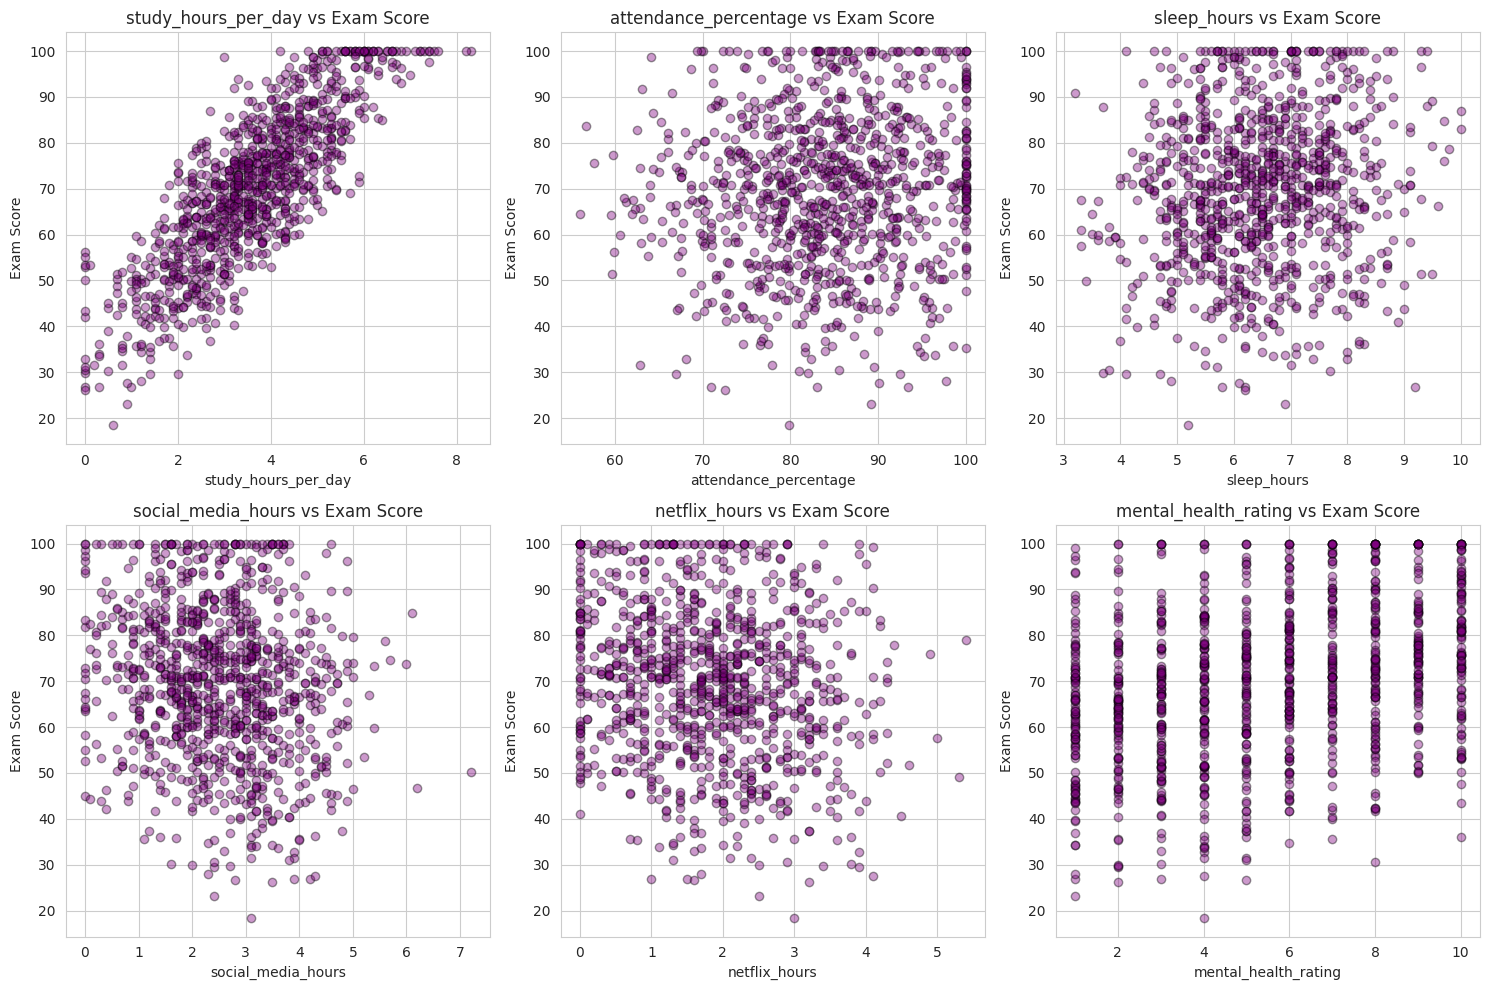

In [11]:
# scatter plots of key numeric features vs exam_score
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

key_features = ['study_hours_per_day', 'attendance_percentage', 'sleep_hours',
                'social_media_hours', 'netflix_hours', 'mental_health_rating']

for i, col in enumerate(key_features):
    axes[i].scatter(df[col], df['exam_score'], alpha=0.4, edgecolor='black', color='purple')
    axes[i].set_title(f'{col} vs Exam Score')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

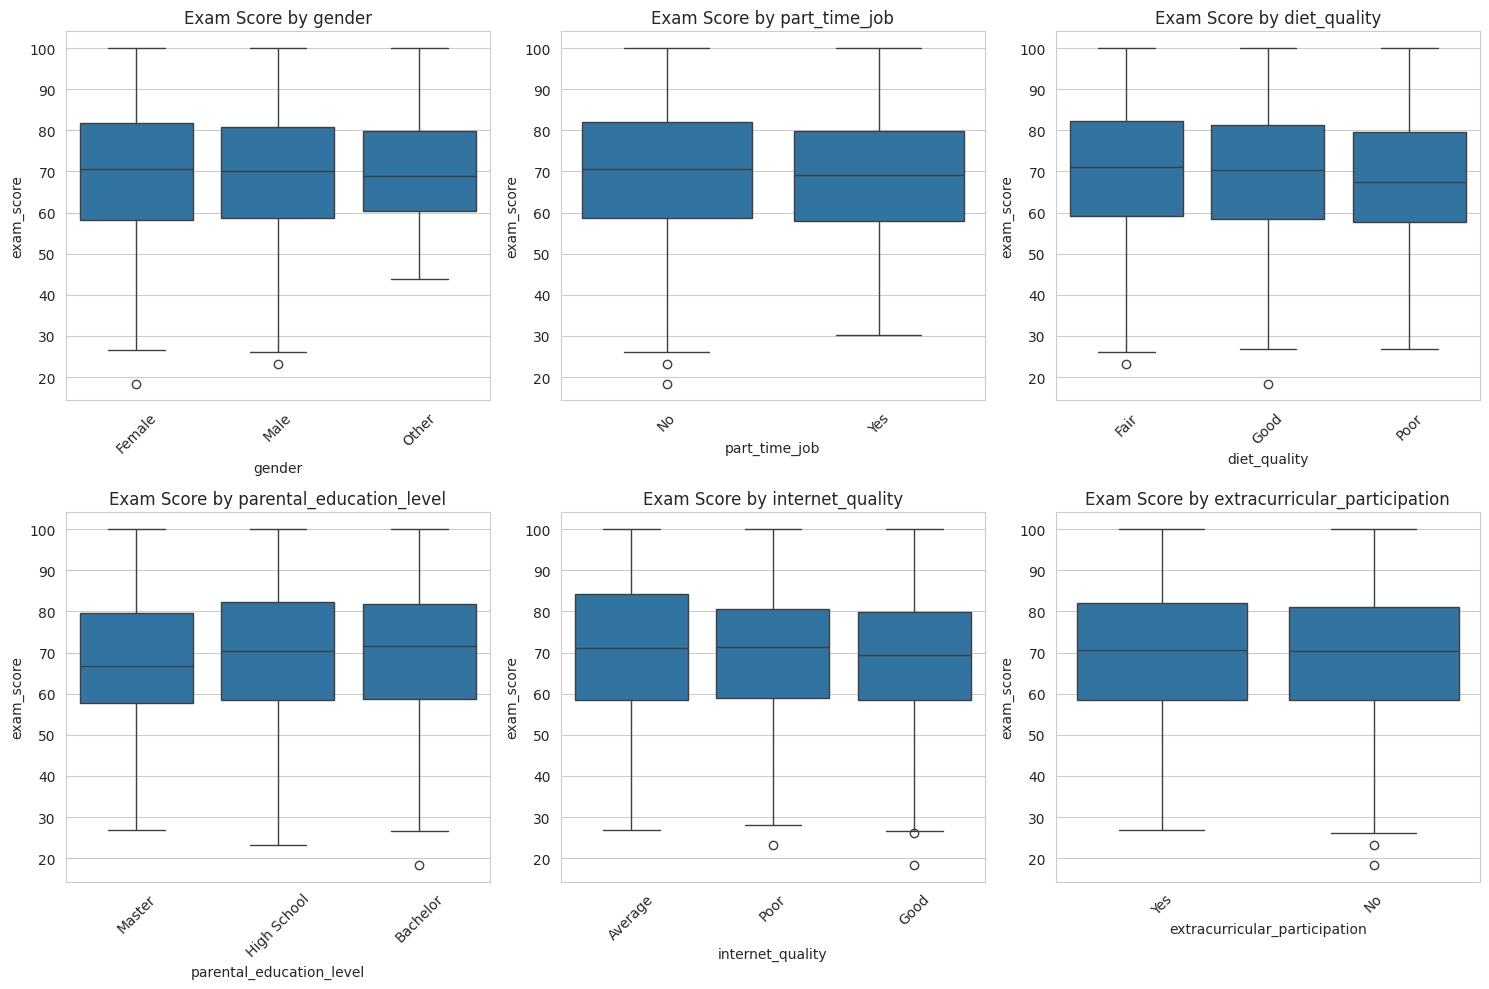

Average Exam Score by Categorical Variable:
-------------------------------------------------------

gender:
gender
Other     70.647619
Female    69.741372
Male      69.368344
Name: exam_score, dtype: float64

part_time_job:
part_time_job
No     69.836561
Yes    68.743256
Name: exam_score, dtype: float64

diet_quality:
diet_quality
Fair    70.428833
Good    69.366402
Poor    68.127568
Name: exam_score, dtype: float64

parental_education_level:
parental_education_level
Bachelor       70.272571
High School    69.638923
Master         68.086826
Name: exam_score, dtype: float64

internet_quality:
internet_quality
Average    70.643990
Poor       69.717284
Good       68.647651
Name: exam_score, dtype: float64

extracurricular_participation:
extracurricular_participation
Yes    69.623270
No     69.591349
Name: exam_score, dtype: float64


In [13]:
# box plots of categorical features vs exam_score
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='exam_score', data=df, ax=axes[i])
    axes[i].set_title(f'Exam Score by {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# group means for each categorical variable
print("Average Exam Score by Categorical Variable:")
print("-" * 55)

for col in cat_cols:
    print(f"\n{col}:")
    print(df.groupby(col)['exam_score'].mean().sort_values(ascending=False))

In [14]:
# drop student_id because it is just an identifier
df_ml = df.drop('student_id', axis=1).copy()

# encode categorical columns to numbers
from sklearn.preprocessing import LabelEncoder

cat_cols = df_ml.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le

print("Encoded categorical columns:")
for col in cat_cols:
    print(f"   {col}: {dict(zip(label_encoders[col].classes_, label_encoders[col].transform(label_encoders[col].classes_)))}")

# final feature list
features = ['study_hours_per_day', 'social_media_hours', 'netflix_hours',
            'attendance_percentage', 'sleep_hours', 'exercise_frequency',
            'mental_health_rating', 'age', 'gender', 'part_time_job',
            'diet_quality', 'parental_education_level', 'internet_quality',
            'extracurricular_participation']

X = df_ml[features]
y = df_ml['exam_score']

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

# preview
print("\nPreview of prepared features:")
print(X.head())

Encoded categorical columns:
   gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
   part_time_job: {'No': np.int64(0), 'Yes': np.int64(1)}
   diet_quality: {'Fair': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}
   parental_education_level: {'Bachelor': np.int64(0), 'High School': np.int64(1), 'Master': np.int64(2)}
   internet_quality: {'Average': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}
   extracurricular_participation: {'No': np.int64(0), 'Yes': np.int64(1)}

Feature matrix shape: (1000, 14)
Target shape: (1000,)

Preview of prepared features:
   study_hours_per_day  social_media_hours  netflix_hours  \
0                  0.0                 1.2            1.1   
1                  6.9                 2.8            2.3   
2                  1.4                 3.1            1.3   
3                  1.0                 3.9            1.0   
4                  5.0                 4.4            0.5   

   attendance_percentage  sleep_

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# split into train and test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# scale the features (important for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling done.")
print("Training set mean (should be ~0):", X_train_scaled.mean().round(4))
print("Training set std (should be ~1):", X_train_scaled.std().round(4))

Training set size: (800, 14)
Testing set size: (200, 14)

Feature scaling done.
Training set mean (should be ~0): -0.0
Training set std (should be ~1): 1.0


In [17]:
from sklearn.linear_model import LinearRegression

# create and train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# generate predictions on both training and testing sets
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

print("Linear Regression model trained.")
print("First 5 predictions on test set:", y_test_pred[:5].round(2))
print("First 5 actual values on test set:", y_test.values[:5])

Linear Regression model trained.
First 5 predictions on test set: [66.32 75.08 77.68 73.91 61.64]
First 5 actual values on test set: [64.2 72.7 79.  79.5 58.2]


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# evaluate on training data
print("Linear Regression - Training Data:")
print("-" * 45)
print("MAE: ", round(mean_absolute_error(y_train, y_train_pred), 4))
print("MSE: ", round(mean_squared_error(y_train, y_train_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 4))
print("R2:  ", round(r2_score(y_train, y_train_pred), 4))

# evaluate on testing data
print("\nLinear Regression - Testing Data:")
print("-" * 45)
print("MAE: ", round(mean_absolute_error(y_test, y_test_pred), 4))
print("MSE: ", round(mean_squared_error(y_test, y_test_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 4))
print("R2:  ", round(r2_score(y_test, y_test_pred), 4))

Linear Regression - Training Data:
---------------------------------------------
MAE:  4.2145
MSE:  28.6952
RMSE: 5.3568
R2:   0.9017

Linear Regression - Testing Data:
---------------------------------------------
MAE:  4.1725
MSE:  26.4977
RMSE: 5.1476
R2:   0.8967


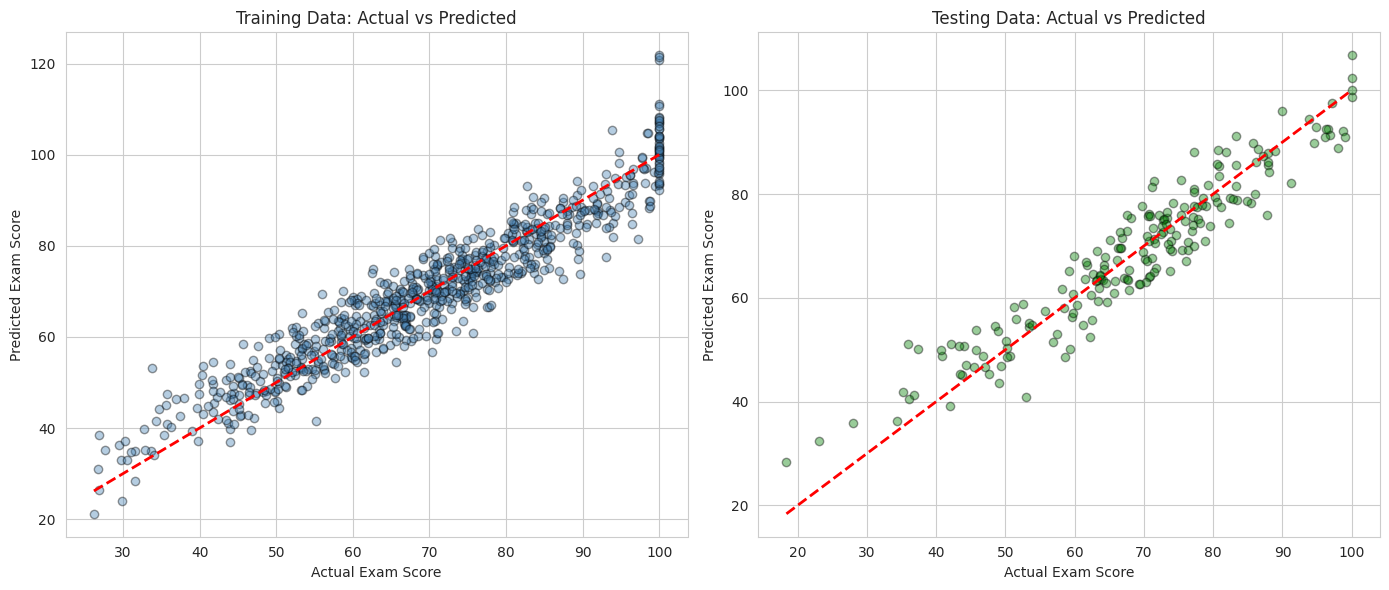

Feature Coefficients (sorted by importance):
-------------------------------------------------------
                      Feature  Coefficient
          study_hours_per_day    14.138044
         mental_health_rating     5.556571
           social_media_hours    -3.135766
           exercise_frequency     2.647497
                netflix_hours    -2.530710
                  sleep_hours     2.445574
        attendance_percentage     1.366815
                 diet_quality    -0.291200
     parental_education_level    -0.262723
                part_time_job     0.144458
                       gender     0.128538
                          age     0.116609
             internet_quality    -0.046838
extracurricular_participation    -0.044120


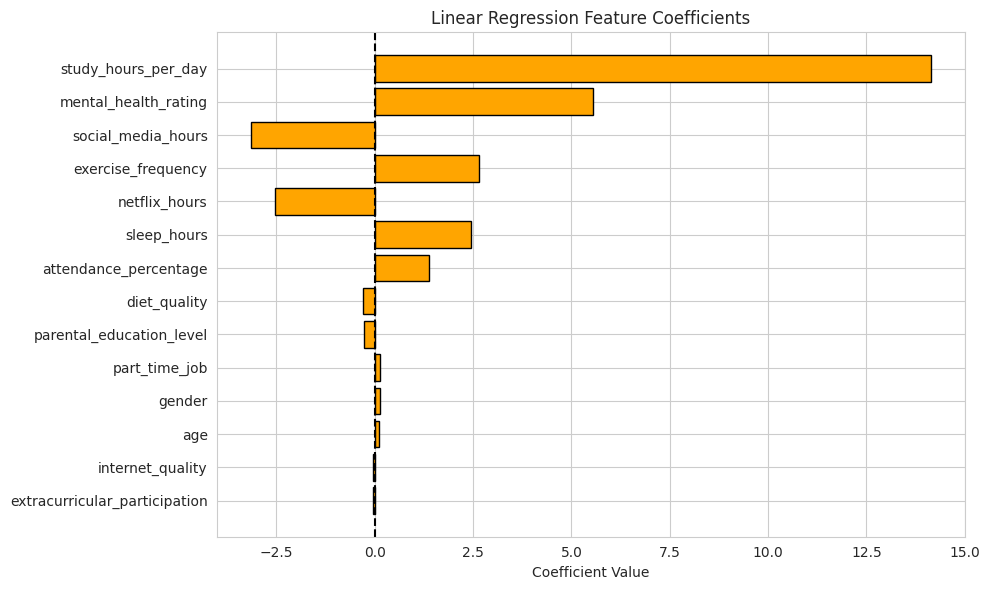

In [19]:
# plot actual vs predicted for train and test
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# training
axes[0].scatter(y_train, y_train_pred, alpha=0.4, edgecolor='black', color='steelblue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
             'r--', linewidth=2)
axes[0].set_xlabel('Actual Exam Score')
axes[0].set_ylabel('Predicted Exam Score')
axes[0].set_title('Training Data: Actual vs Predicted')

# testing
axes[1].scatter(y_test, y_test_pred, alpha=0.4, edgecolor='black', color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2)
axes[1].set_xlabel('Actual Exam Score')
axes[1].set_ylabel('Predicted Exam Score')
axes[1].set_title('Testing Data: Actual vs Predicted')

plt.tight_layout()
plt.show()

# feature coefficients (importance)
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Coefficients (sorted by importance):")
print("-" * 55)
print(coef_df.to_string(index=False))

# plot coefficients
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], edgecolor='black', color='orange')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Feature Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# create binary target: 1 = Pass (score >= 50), 0 = Fail (score < 50)
df_ml['pass_fail'] = (df_ml['exam_score'] >= 50).astype(int)

# check the distribution
print("Pass/Fail distribution:")
print(df_ml['pass_fail'].value_counts())
print("\nPass rate:", round(df_ml['pass_fail'].mean() * 100, 2), "%")
print("Fail rate:", round((1 - df_ml['pass_fail'].mean()) * 100, 2), "%")

# quick sanity check of score ranges in each class
print("\nExam score range for Fail (0):",
      df_ml[df_ml['pass_fail'] == 0]['exam_score'].min(), "to",
      df_ml[df_ml['pass_fail'] == 0]['exam_score'].max())
print("Exam score range for Pass (1):",
      df_ml[df_ml['pass_fail'] == 1]['exam_score'].min(), "to",
      df_ml[df_ml['pass_fail'] == 1]['exam_score'].max())

Pass/Fail distribution:
pass_fail
1    869
0    131
Name: count, dtype: int64

Pass rate: 86.9 %
Fail rate: 13.1 %

Exam score range for Fail (0): 18.4 to 49.9
Exam score range for Pass (1): 50.1 to 100.0


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)

# use the same features, but new target
y_clf = df_ml['pass_fail']

# split with stratify to keep class ratio same in train and test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# scale the features (fit only on train to avoid leakage)
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print("Training set size:", X_train_c.shape)
print("Testing set size:", X_test_c.shape)
print("\nTrain class balance:")
print(y_train_c.value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(y_test_c.value_counts(normalize=True).round(3))

# train logistic regression
clf_model = LogisticRegression(random_state=42, max_iter=1000)
clf_model.fit(X_train_c_scaled, y_train_c)

# generate predictions
y_train_pred_c = clf_model.predict(X_train_c_scaled)
y_test_pred_c = clf_model.predict(X_test_c_scaled)

print("\nLogistic Regression model trained.")
print("First 10 test predictions:", y_test_pred_c[:10])
print("First 10 actual test values:", y_test_c.values[:10])

Training set size: (800, 14)
Testing set size: (200, 14)

Train class balance:
pass_fail
1    0.869
0    0.131
Name: proportion, dtype: float64

Test class balance:
pass_fail
1    0.87
0    0.13
Name: proportion, dtype: float64

Logistic Regression model trained.
First 10 test predictions: [1 0 1 1 1 1 1 1 1 1]
First 10 actual test values: [1 1 1 1 1 1 1 1 1 1]


In [22]:
# evaluate on training data
print("Logistic Regression - Training Data:")
print("-" * 45)
print("Accuracy: ", round(accuracy_score(y_train_c, y_train_pred_c), 4))
print("Precision:", round(precision_score(y_train_c, y_train_pred_c), 4))
print("Recall:   ", round(recall_score(y_train_c, y_train_pred_c), 4))
print("F1-Score: ", round(f1_score(y_train_c, y_train_pred_c), 4))
print("\nConfusion Matrix (Training):")
print(confusion_matrix(y_train_c, y_train_pred_c))

# evaluate on testing data
print("\nLogistic Regression - Testing Data:")
print("-" * 45)
print("Accuracy: ", round(accuracy_score(y_test_c, y_test_pred_c), 4))
print("Precision:", round(precision_score(y_test_c, y_test_pred_c), 4))
print("Recall:   ", round(recall_score(y_test_c, y_test_pred_c), 4))
print("F1-Score: ", round(f1_score(y_test_c, y_test_pred_c), 4))
print("\nConfusion Matrix (Testing):")
print(confusion_matrix(y_test_c, y_test_pred_c))

# full classification report
print("\nClassification Report (Testing):")
print(classification_report(y_test_c, y_test_pred_c, target_names=['Fail', 'Pass']))

Logistic Regression - Training Data:
---------------------------------------------
Accuracy:  0.9537
Precision: 0.9647
Recall:    0.9827
F1-Score:  0.9736

Confusion Matrix (Training):
[[ 80  25]
 [ 12 683]]

Logistic Regression - Testing Data:
---------------------------------------------
Accuracy:  0.96
Precision: 0.9716
Recall:    0.9828
F1-Score:  0.9771

Confusion Matrix (Testing):
[[ 21   5]
 [  3 171]]

Classification Report (Testing):
              precision    recall  f1-score   support

        Fail       0.88      0.81      0.84        26
        Pass       0.97      0.98      0.98       174

    accuracy                           0.96       200
   macro avg       0.92      0.90      0.91       200
weighted avg       0.96      0.96      0.96       200



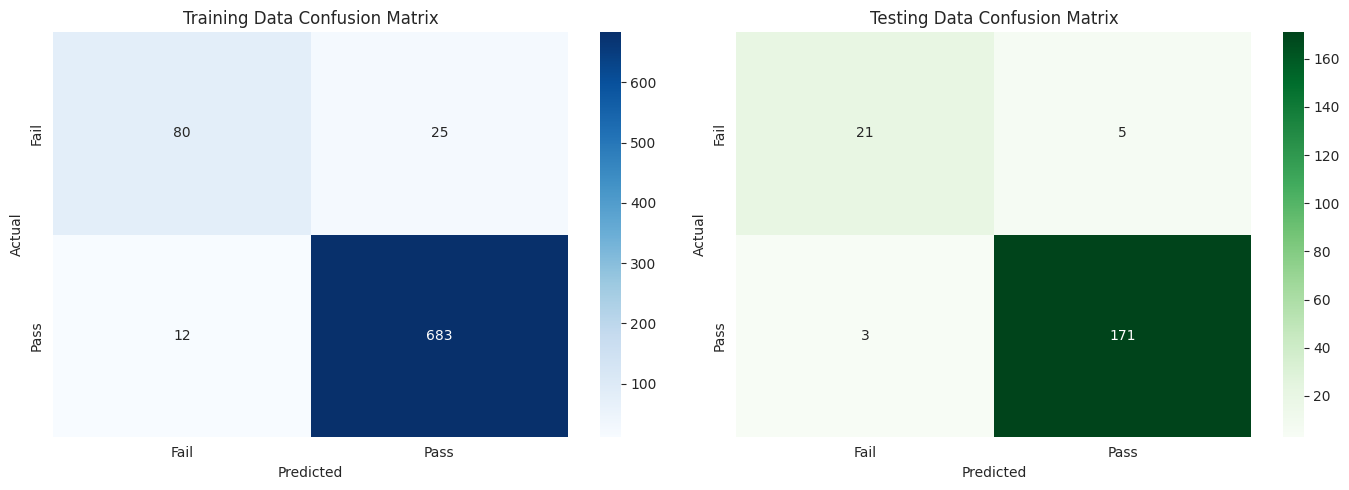

In [23]:
# plot training and testing confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# training confusion matrix
cm_train = confusion_matrix(y_train_c, y_train_pred_c)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
axes[0].set_title('Training Data Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# testing confusion matrix
cm_test = confusion_matrix(y_test_c, y_test_pred_c)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
axes[1].set_title('Testing Data Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [24]:
# build a comparison table for the regression model
reg_compare = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Training': [
        mean_absolute_error(y_train, y_train_pred),
        mean_squared_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        r2_score(y_train, y_train_pred)
    ],
    'Testing': [
        mean_absolute_error(y_test, y_test_pred),
        mean_squared_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        r2_score(y_test, y_test_pred)
    ]
})
reg_compare['Gap'] = (reg_compare['Training'] - reg_compare['Testing']).abs()
reg_compare = reg_compare.round(4)

print("Linear Regression - Training vs Testing:")
print("-" * 55)
print(reg_compare.to_string(index=False))

# build a comparison table for the classification model
clf_compare = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'Training': [
        accuracy_score(y_train_c, y_train_pred_c),
        precision_score(y_train_c, y_train_pred_c),
        recall_score(y_train_c, y_train_pred_c),
        f1_score(y_train_c, y_train_pred_c)
    ],
    'Testing': [
        accuracy_score(y_test_c, y_test_pred_c),
        precision_score(y_test_c, y_test_pred_c),
        recall_score(y_test_c, y_test_pred_c),
        f1_score(y_test_c, y_test_pred_c)
    ]
})
clf_compare['Gap'] = (clf_compare['Training'] - clf_compare['Testing']).abs()
clf_compare = clf_compare.round(4)

print("\nLogistic Regression - Training vs Testing:")
print("-" * 55)
print(clf_compare.to_string(index=False))

Linear Regression - Training vs Testing:
-------------------------------------------------------
Metric  Training  Testing    Gap
   MAE    4.2145   4.1725 0.0420
   MSE   28.6952  26.4977 2.1974
  RMSE    5.3568   5.1476 0.2092
    R2    0.9017   0.8967 0.0050

Logistic Regression - Training vs Testing:
-------------------------------------------------------
   Metric  Training  Testing    Gap
 Accuracy    0.9538   0.9600 0.0062
Precision    0.9647   0.9716 0.0069
   Recall    0.9827   0.9828 0.0000
       F1    0.9736   0.9771 0.0035


In [25]:
# quick summary of the strongest signals for the final write-up
print("Top numeric correlations with exam_score:")
print("-" * 45)
print(df[['study_hours_per_day', 'mental_health_rating', 'social_media_hours',
          'netflix_hours', 'exercise_frequency', 'sleep_hours',
          'attendance_percentage', 'age', 'exam_score']].corr()['exam_score']
      .drop('exam_score').sort_values(ascending=False).round(3))

print("\nAverage exam score by mental health rating:")
print(df.groupby('mental_health_rating')['exam_score'].mean().round(2))

print("\nAverage exam score by study hours bucket:")
df['study_bucket'] = pd.cut(df['study_hours_per_day'],
                            bins=[-0.1, 2, 4, 6, 10],
                            labels=['0-2 hrs', '2-4 hrs', '4-6 hrs', '6+ hrs'])
print(df.groupby('study_bucket')['exam_score'].mean().round(2))

print("\nPass rate by study hours bucket:")
print(df.groupby('study_bucket').apply(
    lambda x: round((x['exam_score'] >= 50).mean() * 100, 1)
))

Top numeric correlations with exam_score:
---------------------------------------------
study_hours_per_day      0.825
mental_health_rating     0.322
exercise_frequency       0.160
sleep_hours              0.122
attendance_percentage    0.090
age                     -0.009
social_media_hours      -0.167
netflix_hours           -0.172
Name: exam_score, dtype: float64

Average exam score by mental health rating:
mental_health_rating
1     62.37
2     63.42
3     64.48
4     65.69
5     66.77
6     71.09
7     74.27
8     74.57
9     76.89
10    77.95
Name: exam_score, dtype: float64

Average exam score by study hours bucket:
study_bucket
0-2 hrs    46.97
2-4 hrs    65.96
4-6 hrs    82.05
6+ hrs     97.77
Name: exam_score, dtype: float64

Pass rate by study hours bucket:
study_bucket
0-2 hrs     43.5
2-4 hrs     90.9
4-6 hrs    100.0
6+ hrs     100.0
dtype: float64


/tmp/ipykernel_3717/1603643132.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('study_bucket')['exam_score'].mean().round(2))
/tmp/ipykernel_3717/1603643132.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('study_bucket').apply(
/tmp/ipykernel_3717/1603643132.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after 

In [26]:
# final summary of model performance and key findings
import numpy as np
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score)

# regression summary
print("Linear Regression Summary:")
print("-" * 45)
reg_summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Training': [
        mean_absolute_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        r2_score(y_train, y_train_pred)
    ],
    'Testing': [
        mean_absolute_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        r2_score(y_test, y_test_pred)
    ]
}).round(4)
print(reg_summary.to_string(index=False))

# classification summary
print("\nLogistic Regression Summary:")
print("-" * 45)
clf_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'Training': [
        accuracy_score(y_train_c, y_train_pred_c),
        precision_score(y_train_c, y_train_pred_c),
        recall_score(y_train_c, y_train_pred_c),
        f1_score(y_train_c, y_train_pred_c)
    ],
    'Testing': [
        accuracy_score(y_test_c, y_test_pred_c),
        precision_score(y_test_c, y_test_pred_c),
        recall_score(y_test_c, y_test_pred_c),
        f1_score(y_test_c, y_test_pred_c)
    ]
}).round(4)
print(clf_summary.to_string(index=False))

# overfitting check
print("\nOverfitting Check (gaps between training and testing):")
print("-" * 45)
print("Regression R2 gap:  ", round(abs(r2_score(y_train, y_train_pred) -
                                         r2_score(y_test, y_test_pred)), 4))
print("Classification F1 gap:", round(abs(f1_score(y_train_c, y_train_pred_c) -
                                            f1_score(y_test_c, y_test_pred_c)), 4))

Linear Regression Summary:
---------------------------------------------
Metric  Training  Testing
   MAE    4.2145   4.1725
  RMSE    5.3568   5.1476
    R2    0.9017   0.8967

Logistic Regression Summary:
---------------------------------------------
   Metric  Training  Testing
 Accuracy    0.9538   0.9600
Precision    0.9647   0.9716
   Recall    0.9827   0.9828
       F1    0.9736   0.9771

Overfitting Check (gaps between training and testing):
---------------------------------------------
Regression R2 gap:   0.005
Classification F1 gap: 0.0035
